<font color='tomato'><font color="#CC3D3D"><p>
# Baseline Code (v2.0)

- `SHAP`을 이용한 Feature selection 코드 추가
- `KMeansFeaturizer`을 이용한 Feature generation 코드 추가

- shap을 통해 피처를 selection하면 feature_importance 쓰는거 보다 정확하니까 효과를 볼수 있음 근데 지금은 피처가 20개 밖에 없으니까 많이 만들어보자
- KMeansFeaturizer 피처를 자동으로 만들어줌 근데 이거 안돌아가던데 ㅋㅋ

##### Imports & Global Setting

In [1]:
import pandas as pd
import numpy as np
import os
import random
import pickle
import gzip
import gc
import re
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib import font_manager, rc
from tqdm import tqdm, tqdm_notebook
%matplotlib inline

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
# import winsound as sd
# def beepsound():
#     fr = 2000    # range : 37 ~ 32767
#     du = 1000    # 1000 ms ==1second
#     sd.Beep(fr, du) # winsound.Beep(frequency, duration)
import shap # v2.0부터 추가

In [2]:
VERSION = 2.0
SHAP_THRESHOLD = 0.001  # v2.0부터 추가

# 01. Data Loading

In [3]:
train = pd.read_csv('../../data/train.csv', encoding='cp949')
test = pd.read_csv('../../data/test.csv', encoding='cp949')

In [4]:
original_features = train.columns
original_features

Index(['userID', 'surveyID', 'BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ1', 'SQ2',
       'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4',
       'B5', 'C1', 'C2', 'C3', 'F1', 'F2', 'H1', 'T1', 'X1', 'X2', 'X3', 'X4',
       'DQ1', 'DQ2', 'DQ3', 'DQ4', 'DQ5', 'DQ6', 'DQ7', 'TITLE', 'IR', 'LOI',
       'CATEGORIES', 'CPI', 'STATUS'],
      dtype='object')

### 데이터 설명
- **패널(Panel) 데이터**
  - userID: 패널 ID
  - BIRTH: 생일(연도)
  - GENDER: 1(남자) 2(여자)
  - REGION: 거주지역
  - TYPE: 패널 구분
  - SQ1 ~ DQ7: 패널 가입 시 설문조사 데이터로 각 필드에 대한 [상세설명](https://docs.google.com/spreadsheets/d/1pY6MYTSkyHrGLmMTU8tX_xlD8fPut6Ob/edit?usp=sharing&ouid=107121563618260277687&rtpof=true&sd=true) 참조
- **설문(Survey) 데이터**
  - surveyID: 설문 ID
  - TITLE: 설문 제목
  - IR: 난이도(응답가능성, 100이 최고)
  - LOI: 설문하는데 걸리는 시간 (분단위)
  - CATEGORIES: 설문 분류
  - CPI: 패널 응답 리워드 포인트(1P~)
- **응답(Response) 데이터**
  - STATUS: 응답여부 (Target)
  - (test 데이터의) ID: submission을 식별하기 위한 ID로 사용

- SQ1 ~ DQ7 결측치도 많고 이게 응답률에 의미가 있을까?

- IR 숫자가 높을 수록 난이도 높
- LOI -시간
- CPI -리워드

* 설문응답률 설문데이터관련 피처가 중요할 것같음
* 테스트에서 ID는 인덱스의 의미
* 결측치 개많!
* 30%이하피쳐는 안썼음


# 02. Data Preprocessing

##### Clean data & derive features

In [5]:
# 결측값 비율이 30% 이하인 column만 사용(사용할 피처들만 출력)
features = []
for f in train.columns:
    if train[f].isnull().sum()/train.shape[0] <= 0.3:
        print(f, '\t', train[f].nunique(), '\t', train[f].isnull().sum()/train.shape[0])
        features.append(f)

userID 	 15155 	 0.0
surveyID 	 1293 	 0.0
BIRTH 	 76 	 0.0
GENDER 	 2 	 0.0
REGION 	 17 	 0.0
TYPE 	 3 	 0.0
SQ1 	 2 	 0.0009770785964481042
SQ2 	 82 	 0.0014293615190806859
SQ3 	 47 	 0.09023044306520002
SQ4 	 52 	 0.09058931973207153
SQ5 	 273 	 0.14450930989983407
SQ6 	 30 	 0.14490751551649972
SQ7 	 1234 	 0.1802556381736619
SQ8 	 1774 	 0.1831610643397038
A1 	 2768 	 0.2083279051189086
B1 	 131 	 0.21447796964296686
B2 	 120 	 0.2426792847047256
B3 	 110 	 0.24790757696798377
B4 	 715 	 0.2602888219750507
B5 	 669 	 0.26743317151109197
TITLE 	 1286 	 0.0
IR 	 42 	 0.0
LOI 	 26 	 0.0
CPI 	 43 	 0.0
STATUS 	 2 	 0.0


In [6]:
# 불필요한 ID들은 제외. SQ1 ~ SQ3는 GENDER, BIRTH, REGION과 중복이어서 제외!
features.remove('userID')
features.remove('surveyID')
features.remove('STATUS')
features.remove('SQ1')
features.remove('SQ2')
features.remove('SQ3')

In [7]:
# 거주 주택 형태: 1/2/3/4/5/6/97이 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,']:
        return int(x[0])
    else:
        return 99

train.SQ4 = train.SQ4.apply(handle_profile)
test.SQ4 = test.SQ4.apply(handle_profile)

In [8]:
# 최종학력: 1/2/3/4 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4']:
        return int(x)
    elif x in ['1.0', '2.0', '3.0', '4.0']:
        return int(x[0])
    else:
        return 99

train.SQ5 = train.SQ5.apply(handle_profile)
test.SQ5 = test.SQ5.apply(handle_profile)

In [9]:
# 결혼여부: 1/2/97 정상값
def handle_profile(x):
    if x in ['1', '2']:
        return int(x)
    elif x in ['1,', '2,']:
        return int(x[0])
    else:
        return 99

train.SQ6 = train.SQ6.apply(handle_profile)
test.SQ6 = test.SQ6.apply(handle_profile)

In [10]:
# 자녀 정보: 1~16/99 정상값
value1 = pd.Series(range(1,17)).apply(lambda x: str(x)).tolist()
value2 = pd.Series(np.arange(1.0,17.0)).apply(lambda x: str(x)).tolist()
def handle_profile(x):
    if x in value1:
        return int(x)
    elif x in value2:
        return int(x[0])
    else:
        return 99

train.SQ7 = train.SQ7.apply(handle_profile)
test.SQ7 = test.SQ7.apply(handle_profile)

In [11]:
# 가족수: 1/2/3/4/5 정상값
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5']:
        return int(x)
    else:
        return 99

train.SQ8 = train.SQ8.apply(handle_profile)
test.SQ8 = test.SQ8.apply(handle_profile)

In [12]:
# 최근 구입/렌트 가전제품: 1~22/99 정상값

## 최근 구매 사실에 대해서 설문조사를 진행했을 확률이 있을까?
values = pd.Series(range(1,23)).apply(lambda x: str(x)).tolist()
def handle_profile(x):    
    if x in values:
        return int(x)
    else:
        return 99

train.A1 = train.A1.apply(handle_profile)
test.A1 = test.A1.apply(handle_profile)

In [13]:
# 휴대폰 통신망 종류: 1~8/99 정상값
def handle_profile(x):    
    if x in ['1']:
        return 2
    elif x in ['2', '3']:
        return 3
    elif x in ['4', '5', '6', '7']:
        return 4
    elif x in ['8']:
        return 5
    else:
        return 99

train.B1 = train.B1.apply(handle_profile)
test.B1 = test.B1.apply(handle_profile)

In [14]:
# 가입한 이동통신사: 1~6/97 정상값 
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6']:
        return int(x)
    else:
        return 99

train.B2 = train.B2.apply(handle_profile)
test.B2 = test.B2.apply(handle_profile)

In [15]:
# 휴대폰 브랜드: 1~7/97/99 --1등
def handle_profile(x):    
    if x in ['1', '2', '3']:
        return int(x)
    elif x in ['1,', '2,', '3,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B3 = train.B3.apply(handle_profile)
test.B3 = test.B3.apply(handle_profile)

In [16]:
# 보유 스마트 기기: 1~7/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4', '5', '6', '7' , '99', '97']:
        return int(x)
    else:
        return 98

train.B4 = train.B4.apply(handle_profile)
test.B4 = test.B4.apply(handle_profile)

In [17]:
# 케이블TV: 1~10/97/99  --1등
def handle_profile(x):    
    if x != x :
        return 0
    elif x in ['1', '2', '3', '4' ,'5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,' ,'5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    elif x in ['99', '99,']:
        return 99
    else:
        return 4  # 기타 제조사

train.B5 = train.B5.apply(handle_profile)
test.B5 = test.B5.apply(handle_profile)

In [18]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C1 = train.C1.apply(handle_profile)
test.C1 = test.C1.apply(handle_profile)

In [19]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,', '11,', '12,', '13,', '14,']:
        return int(x[0])
    else:
        return 99

train.C2 = train.C2.apply(handle_profile)
test.C2 = test.C2.apply(handle_profile)

In [20]:
def handle_profile(x):
    if x in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']:
        return int(x)
    elif x in ['1,', '2,', '3,', '4,', '5,', '6,', '7,', '8,', '9,', '10,']:
        return int(x[0])
    else:
        return 99

train.C3 = train.C3.apply(handle_profile)
test.C3 = test.C3.apply(handle_profile)

# 03. Feature Generation(FE_GN)

<span style ="color:red">

---
---

# 확정된 피처

In [21]:
# 00. 응답률(RESRATE) 생성
res_freq = train.query('STATUS == 1').groupby('userID')['userID'].agg([('FREQ',np.size)]).reset_index()
send_freq = train.groupby('userID')['userID'].agg([('SEND',np.size)]).reset_index()

train = train.merge(res_freq, how='left').merge(send_freq, how='left')
train['RESRATE'] = train['FREQ'] / train['SEND']
del train['FREQ'], train['SEND']
test = pd.merge(test, train.drop_duplicates(subset=['userID'])[['userID', 'RESRATE']], how='left')
test['RESRATE'] = test['RESRATE'].fillna(0)
### 결측값을 이렇게 처리하는게 최선일까?

#features.extend(['RESRATE'])    --> 피처 추가는 round된 버전으로!

In [22]:
### 확정
# RESRATE구간화(이게맞나) 2441개 값이 -> 993 맞는것같기도하고
train['RESRATE_round'] = round(train['RESRATE'],3) 
test['RESRATE_round'] = round(test['RESRATE'],3) 

features.extend(['RESRATE_round'])

In [23]:
### 확정
# 02. 타입별 응답률 ??타입이 뭐임 근데 (올라감)
response = train.groupby('TYPE')['STATUS'].agg([('TYPE_RES_RATE', lambda x: np.mean(x))]).reset_index()
train = train.merge(response, how='left', on='TYPE')
test = test.merge(response, how='left', on='TYPE')

features.extend(['TYPE_RES_RATE'])

In [24]:
### 확정--> 아래 코드에서 대체 / 아직 돌려보진 않음
'''# 04 -(시간+난이도)  
train['-(시간+난이도)'] = -train['IR'] - train['LOI']
test['-(시간+난이도)'] = -test['IR'] - test['LOI']
features.extend(['-(시간+난이도)'])'''

"# 04 -(시간+난이도)  \ntrain['-(시간+난이도)'] = -train['IR'] - train['LOI']\ntest['-(시간+난이도)'] = -test['IR'] - test['LOI']\nfeatures.extend(['-(시간+난이도)'])"

In [25]:
### 확정
# 05. 생일 구간, 생일 구간
# BIRTH 구간 나누기
bins = list(range(1920, 2020, 10))
bins_label = [str(x)+"~ "+str(x+10) for x in bins]

train["BIRTH_range"] = pd.cut(train["BIRTH"], bins, right=False, labels = bins_label[:-1])
test["BIRTH_range"] = pd.cut(test["BIRTH"], bins, right=False, labels = bins_label[:-1])

# features.extend(['BIRTH_range'])

In [26]:
# 14. 패널 ID 별 획득 누적 포인트.
#Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()
Points_earned = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned',np.sum)])).reset_index()

# 패널 ID 별 획득 평균 포인트
Points_earned_mean = pd.DataFrame(train.query('STATUS==1').groupby('userID')['CPI'].agg([('Points_earned_mean',np.mean)])).reset_index()

train = train.merge(Points_earned, how='left')
train = train.merge(Points_earned_mean, how='left')
train['Points_earned'].fillna(0, inplace = True)
train['Points_earned_mean'].fillna(0, inplace = True)

test = test.merge(Points_earned, how='left')
test = test.merge(Points_earned_mean, how='left')
test['Points_earned'].fillna(0, inplace = True)
test['Points_earned_mean'].fillna(0, inplace = True)

#features.extend(['Points_earned_mean'])

In [27]:
### 확정 (올라가긴했는데 구간화 더 잘하면 더 좋아질 수 있을 것같기도 함 근데 어케 더 잘헤야하지 )
# 0부터 1170까지는 20씩, 1200에서 2000까지는 하나의 구간으로 설정
bin_edges = list(range(0, 1200, 20)) + [2000]

# 구간에 대한 라벨 설정
bin_labels = [f'{i}-{i+19}' for i in range(0, 1180, 20)] + ['1200-2000']

# 'Points_earned_mean' 열을 구간화하여 새로운 열로 추가
train['Points_earned_bins'] = pd.cut(train['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)
test['Points_earned_bins'] = pd.cut(test['Points_earned_mean'], bins=bin_edges, labels=bin_labels, include_lowest=True)

features.append('Points_earned_bins')

### **< TITLE >** 피처


In [28]:
train_TITLE = train.copy()
test_TITLE = test.copy()

##### **TITLE 1)** 기존의 TITLE 컬럼 값을 아예 수정하는 코드
- ***train, test*** 사용


In [29]:
# Survey 제목에서 유용한 정보 추출 
# train.TITLE.value_counts()
### 약 
word_counts = {}
def count_word(x): # 응답한 서베이 제목에서 한글 단어만 분리하고 빈도 계산
    if x['STATUS'] == 1:
        for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
            word_counts[w] = word_counts.get(w, 0) + 1
def score_word(x): # 빈도의 합으로 제목을 Encoding
    score = 0
    for w in re.sub(r'[^ ㄱ-ㅣ가-힣]', '', x['TITLE']).split():
        score += word_counts.get(w, 0)
    return score    
            
train.apply(count_word, axis=1)
train.TITLE = train.apply(score_word, axis=1)
test.TITLE = test.apply(score_word, axis=1)

<span style ="color:red">

---
---

In [30]:
# 03
train['리워드/시간'] = train['CPI'] / train['LOI']
test['리워드/시간'] = test['CPI'] / test['LOI']
features.extend(['리워드/시간'])

- 스케일 등 작업 후

In [31]:
'''# 시간과 난이도의 합을 계산하여 새로운 피처 생성
train['-(시간+난이도)'] = -(train['IR'] + train['LOI'])
test['-(시간+난이도)'] = -(test['IR'] + test['LOI'] )
features.extend(['-(시간+난이도)'])'''

"# 시간과 난이도의 합을 계산하여 새로운 피처 생성\ntrain['-(시간+난이도)'] = -(train['IR'] + train['LOI'])\ntest['-(시간+난이도)'] = -(test['IR'] + test['LOI'] )\nfeatures.extend(['-(시간+난이도)'])"

In [32]:
### -(시간+난이도) 스케일링
# IR와 LOI를 각각 스케일링 후 연산
from sklearn.preprocessing import MinMaxScaler

# IR 피처에 대한 Min-Max Scaling
scaler = MinMaxScaler(feature_range=(1, 35))  # LOI의 범위에 맞춰서 설정
train['IR_scaled'] = scaler.fit_transform(train['IR'].values.reshape(-1, 1))
test['IR_scaled'] = scaler.fit_transform(test['IR'].values.reshape(-1, 1))

# 시간과 난이도의 합을 계산하여 새로운 피처 생성
train['-(시간+난이도)_scaled'] = -(train['IR_scaled'] + train['LOI'])
test['-(시간+난이도)_scaled'] = -(test['IR_scaled'] + test['LOI'] )
features.extend(['-(시간+난이도)_scaled'])

---

In [33]:
# 10. 응답률 * 서베이 횟수
survey_count = train.groupby('userID')['userID'].count()#.reset_index()
survey_count.name = 'user'
survey_count.reset_index()
RES_RATE = train.STATUS.groupby(train.userID).sum() / train.STATUS.groupby(train.userID).count()

RES_RATE_survey_sum = RES_RATE*survey_count
RES_RATE_survey_sum.name = 'RES_RATE_survey_sum'

train = train.merge(RES_RATE_survey_sum,on='userID', how = 'left')
test = test.merge(RES_RATE_survey_sum,on='userID', how = 'left')
# features.extend(['RES_RATE_survey_sum'])'

In [34]:
### RES_RATE_survey_sum 로그 변환
train['RES_RATE_survey_sum_log'] = np.log(train['RES_RATE_survey_sum'] + 1)  # +1을 더해줘서 0이하의 값이 없도록 보정
test['RES_RATE_survey_sum_log'] = np.log(test['RES_RATE_survey_sum'] + 1)  # +1을 더해줘서 0이하의 값이 없도록 보정
features.extend(['RES_RATE_survey_sum_log'])

In [35]:
'''### RES_RATE_survey_sum 루트 변환
train['RES_RATE_survey_sum_root'] = np.sqrt(train['RES_RATE_survey_sum'])
test['RES_RATE_survey_sum_root'] = np.sqrt(test['RES_RATE_survey_sum'])
features.extend(['RES_RATE_survey_sum_root'])'''

"### RES_RATE_survey_sum 루트 변환\ntrain['RES_RATE_survey_sum_root'] = np.sqrt(train['RES_RATE_survey_sum'])\ntest['RES_RATE_survey_sum_root'] = np.sqrt(test['RES_RATE_survey_sum'])\nfeatures.extend(['RES_RATE_survey_sum_root'])"

In [36]:
'''### RES_RATE_survey_sum 스케일 변환
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train['RES_RATE_survey_sum_scaled'] = scaler.fit_transform(train['RES_RATE_survey_sum'].values.reshape(-1, 1))
test['RES_RATE_survey_sum_scaled'] = scaler.transform(test['RES_RATE_survey_sum'].values.reshape(-1, 1))
features.extend(['RES_RATE_survey_sum_scaled'])'''

"### RES_RATE_survey_sum 스케일 변환\nfrom sklearn.preprocessing import MinMaxScaler\nscaler = MinMaxScaler()\n\ntrain['RES_RATE_survey_sum_scaled'] = scaler.fit_transform(train['RES_RATE_survey_sum'].values.reshape(-1, 1))\ntest['RES_RATE_survey_sum_scaled'] = scaler.transform(test['RES_RATE_survey_sum'].values.reshape(-1, 1))\nfeatures.extend(['RES_RATE_survey_sum_scaled'])"

<span style="color:#33FF33">

---

# 추가!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!(아현)

##### **TITLE 2)** **Word2Vec** 로 피처 생성
- ~ Title_W2V_99
- ***train_TITLE, test_TITLE*** 사용
- 상위 팀들한테 언급 된 친구</br>
- 단어 벡터는 단어를 수학적(벡터)으로 표현한 것</br>
- Word2Vec은 텍스트 데이터를 가져와 각 단어를 고차원 공간 상의 점으로 표현하는 것 </br>
 같은 문맥에서 함께 등장하는 단어들은 공간상에서 가까이 위치하게 됨. 예를 들어, "왕"과 "여왕"은 비슷한 문맥에서 자주 함께 등장하기 때문에, Word2Vec 공간에서 이 두 단어는 가까이 위치할 것

In [37]:
'''
# pip install gensim
# pip install nltk
from gensim.models import Word2Vec
import nltk
# nltk.download('punkt')  # 필요한 경우 punkt 다운로드
### 약 6~7분 걸림
# 'TITLE' 피처에서 문장을 단어로 분할하여 리스트로 변환
sentences = [nltk.word_tokenize(title) for title in train_TITLE['TITLE']]

# Word2Vec 모델 학습
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# 'TITLE'을 Word2Vec 벡터로 변환하여 새로운 피처 생성
def get_mean_vector(words, model, vector_size):
    # 단어 벡터의 평균을 계산하여 문장 벡터 반환
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) > 0:
        return pd.Series(vectors).mean()
    else:
        return pd.Series([0] * vector_size)  # 만약 단어가 없으면 0 벡터 반환

# 새로운 피처 생성
new_columns = ['W2V_' + str(i) for i in range(100)]
vectorized_titles = train_TITLE['TITLE'].apply(lambda x: get_mean_vector(nltk.word_tokenize(x), model, 100))
train_TITLE[new_columns] = pd.DataFrame(vectorized_titles.tolist())'''

"\n# pip install gensim\n# pip install nltk\nfrom gensim.models import Word2Vec\nimport nltk\n# nltk.download('punkt')  # 필요한 경우 punkt 다운로드\n### 약 6~7분 걸림\n# 'TITLE' 피처에서 문장을 단어로 분할하여 리스트로 변환\nsentences = [nltk.word_tokenize(title) for title in train_TITLE['TITLE']]\n\n# Word2Vec 모델 학습\nmodel = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)\n\n# 'TITLE'을 Word2Vec 벡터로 변환하여 새로운 피처 생성\ndef get_mean_vector(words, model, vector_size):\n    # 단어 벡터의 평균을 계산하여 문장 벡터 반환\n    vectors = [model.wv[word] for word in words if word in model.wv]\n    if len(vectors) > 0:\n        return pd.Series(vectors).mean()\n    else:\n        return pd.Series([0] * vector_size)  # 만약 단어가 없으면 0 벡터 반환\n\n# 새로운 피처 생성\nnew_columns = ['W2V_' + str(i) for i in range(100)]\nvectorized_titles = train_TITLE['TITLE'].apply(lambda x: get_mean_vector(nltk.word_tokenize(x), model, 100))\ntrain_TITLE[new_columns] = pd.DataFrame(vectorized_titles.tolist())"

In [38]:
'''### 약 2분
train[new_columns] = pd.DataFrame(vectorized_titles.tolist())
test[new_columns] = pd.DataFrame(vectorized_titles.tolist())
features.extend(new_columns)'''

'### 약 2분\ntrain[new_columns] = pd.DataFrame(vectorized_titles.tolist())\ntest[new_columns] = pd.DataFrame(vectorized_titles.tolist())\nfeatures.extend(new_columns)'

<span style="color:#33FF33">

---

##### **TITLE 3)** 대상지역과 대상자유형 컬럼 생성
- ***train_TITLE, test_TITLE*** 사용


In [39]:
### 확정
### train
### 1등 코드
'''!!! Survey 제목에서 유용한 정보 추출 컬럼이랑 위치 바꾸면 오류남!!!!'''
대상지역 = np.where(train_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(train_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(train_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

### 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

### 데이터프레임에 병합
train = pd.concat([train, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)
features.extend(['대상지역', '대상자유형_일반인', '대상자유형_소비자'])

In [40]:
### 확정
### test
### 1등 코드
'''!!! Survey 제목에서 유용한 정보 추출 컬럼이랑 위치 바꾸면 오류남!!!!'''

대상지역 = np.where(test_TITLE['TITLE'].str.contains('해외'), '해외', '기타')
대상자유형_일반인 = np.where(test_TITLE['TITLE'].str.contains('일반인'), '일반인', '기타')
대상자유형_소비자 = np.where(test_TITLE['TITLE'].str.contains('소비자'), '소비자', '기타')

### 생성된 배열을 시리즈로 변환
대상지역 = pd.Series(대상지역, name='대상지역')
대상자유형_일반인 = pd.Series(대상자유형_일반인, name='대상자유형_일반인')
대상자유형_소비자 = pd.Series(대상자유형_소비자, name='대상자유형_소비자')

### 데이터프레임에 병합
test = pd.concat([test, 대상지역, 대상자유형_일반인, 대상자유형_소비자], axis=1)

<span style="color:#33FF33">

---

# 추가!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!(아현)


# **구간화**

In [41]:
# LOI:설문 시간(분)
# CPI:리워드 포인트(1P~)
# IR :난이도
# RESRATE_round: 응답률 반올림 구간화

- LOI

In [42]:
'''# 0부터 100%까지의 분위수를 기준으로 구간화
bins_train = train['LOI'].quantile([0, 0.25, 0.5, 0.75, 1]).values
bins_test = test['LOI'].quantile([0, 0.25, 0.5, 0.75, 1]).vaㅇlues

# 중복값 제거
bins_train_unique = np.unique(bins_train)
bins_test_unique = np.unique(bins_test)

# 구간화 수행해서 대체
train['LOI_section'] = pd.cut(train['LOI'], bins=bins_train_unique)
test['LOI_section'] = pd.cut(test['LOI'], bins=bins_test_unique)'''

"# 0부터 100%까지의 분위수를 기준으로 구간화\nbins_train = train['LOI'].quantile([0, 0.25, 0.5, 0.75, 1]).values\nbins_test = test['LOI'].quantile([0, 0.25, 0.5, 0.75, 1]).vaㅇlues\n\n# 중복값 제거\nbins_train_unique = np.unique(bins_train)\nbins_test_unique = np.unique(bins_test)\n\n# 구간화 수행해서 대체\ntrain['LOI_section'] = pd.cut(train['LOI'], bins=bins_train_unique)\ntest['LOI_section'] = pd.cut(test['LOI'], bins=bins_test_unique)"

- CPI

In [43]:
'''# 데이터프레임과 구간화할 특정 수치형 열 선택
numeric_column = 'CPI'  # 구간화하려는 수치형 변수의 컬럼명 입력

# 구간화할 기준값 설정
threshold_value_low = 300  # 낮은 구간의 기준값 설정
threshold_value_high = 800  # 높은 구간의 기준값 설정

# 두 개의 기준값을 이용하여 구간 분리,  대체
train['CPI_section'] = np.where(train['CPI'] <= threshold_value_low, 'Low',
                                 np.where(train['CPI'] <= threshold_value_high, 'Medium', 'High'))

test['CPI_section'] = np.where(test['CPI'] <= threshold_value_low, 'Low',
                                np.where(test['CPI'] <= threshold_value_high, 'Medium', 'High'))'''

"# 데이터프레임과 구간화할 특정 수치형 열 선택\nnumeric_column = 'CPI'  # 구간화하려는 수치형 변수의 컬럼명 입력\n\n# 구간화할 기준값 설정\nthreshold_value_low = 300  # 낮은 구간의 기준값 설정\nthreshold_value_high = 800  # 높은 구간의 기준값 설정\n\n# 두 개의 기준값을 이용하여 구간 분리,  대체\ntrain['CPI_section'] = np.where(train['CPI'] <= threshold_value_low, 'Low',\n                                 np.where(train['CPI'] <= threshold_value_high, 'Medium', 'High'))\n\ntest['CPI_section'] = np.where(test['CPI'] <= threshold_value_low, 'Low',\n                                np.where(test['CPI'] <= threshold_value_high, 'Medium', 'High'))"

- IR (난이도)

In [44]:
'''# 구간화할 컬럼 선택
numeric_column = 'IR'  # 수치형 변수 선택

# 구간을 나누기 위한 범위 설정
bins = [0, 30, 60, 90, 100]  # 임의의 구간 설정

# 구간화 수행해서  대체
train['IR_section'] = pd.cut(train['IR'], bins=bins)
test['IR_section'] = pd.cut(test['IR'], bins=bins)'''

"# 구간화할 컬럼 선택\nnumeric_column = 'IR'  # 수치형 변수 선택\n\n# 구간을 나누기 위한 범위 설정\nbins = [0, 30, 60, 90, 100]  # 임의의 구간 설정\n\n# 구간화 수행해서  대체\ntrain['IR_section'] = pd.cut(train['IR'], bins=bins)\ntest['IR_section'] = pd.cut(test['IR'], bins=bins)"

# **교수님 팁**
https://www.kaggle.com/c/otto-group-product-classification-challenge/discussion/14335

In [45]:
'''train['CATEGORIES'].value_counts'''

"train['CATEGORIES'].value_counts"

In [46]:
'''from sklearn.neighbors import NearestNeighbors

# 데이터 준비
data = train['IR_section'].values.reshape(-1, 1)  # 수치형 피처 데이터

# KNN 모델 생성
knn = NearestNeighbors(n_neighbors=4)  # 4개의 가장 가까운 이웃 설정
knn.fit(data)

# 각 데이터 포인트의 이웃과의 거리 계산
distances, indices = knn.kneighbors(data)

# 각 클래스별로 네 개의 가장 가까운 이웃과의 거리를 합산하여 새로운 피처 생성
train['IR_section_KNN'] = np.sum(distances, axis=1)'''

"from sklearn.neighbors import NearestNeighbors\n\n# 데이터 준비\ndata = train['IR_section'].values.reshape(-1, 1)  # 수치형 피처 데이터\n\n# KNN 모델 생성\nknn = NearestNeighbors(n_neighbors=4)  # 4개의 가장 가까운 이웃 설정\nknn.fit(data)\n\n# 각 데이터 포인트의 이웃과의 거리 계산\ndistances, indices = knn.kneighbors(data)\n\n# 각 클래스별로 네 개의 가장 가까운 이웃과의 거리를 합산하여 새로운 피처 생성\ntrain['IR_section_KNN'] = np.sum(distances, axis=1)"

In [47]:
'''
# 네 개의 클래스로 분류합니다.
class_1_indices = train[train['IR'] < threshold_1].index
class_2_indices = train[(train['IR'] >= threshold_1) & (train['IR'] < threshold_2)].index
class_3_indices = train[(train['IR'] >= threshold_2) & (train['IR'] < threshold_3)].index
class_4_indices = train[train['IR'] >= threshold_3].index


# KNN을 사용하여 각 클래스별로 네 개의 가장 가까운 이웃을 찾습니다.
n_neighbors = 4  # 네 개의 이웃을 찾습니다.
knn = NearestNeighbors(n_neighbors=n_neighbors)

# 각 클래스별로 이웃을 찾고 거리를 합산합니다.
distances_sum_class_1 = []
distances_sum_class_2 = []

# 클래스 1에 대한 이웃 찾기와 거리 합산
for idx in class_1_indices:
    # 현재 샘플과 이웃들의 거리를 계산합니다.
    knn.fit(X_train)  # X_train은 데이터셋의 특성 값들입니다.
    distances, neighbors = knn.kneighbors([X_train[idx]], n_neighbors=n_neighbors)
    
    # 거리 합산
    distances_sum_class_1.append(np.sum(distances))

# 클래스 2에 대한 이웃 찾기와 거리 합산
for idx in class_2_indices:
    # 현재 샘플과 이웃들의 거리를 계산합니다.
    knn.fit(X_train)  # X_train은 데이터셋의 특성 값들입니다.
    distances, neighbors = knn.kneighbors([X_train[idx]], n_neighbors=n_neighbors)
    
    # 거리 합산
    distances_sum_class_2.append(np.sum(distances))

# 거리 합산한 값을 피처로 만듭니다.
train['Sum_of_distances_class_1'] = distances_sum_class_1
train['Sum_of_distances_class_2'] = distances_sum_class_2
'''

"\n# 네 개의 클래스로 분류합니다.\nclass_1_indices = train[train['IR'] < threshold_1].index\nclass_2_indices = train[(train['IR'] >= threshold_1) & (train['IR'] < threshold_2)].index\nclass_3_indices = train[(train['IR'] >= threshold_2) & (train['IR'] < threshold_3)].index\nclass_4_indices = train[train['IR'] >= threshold_3].index\n\n\n# KNN을 사용하여 각 클래스별로 네 개의 가장 가까운 이웃을 찾습니다.\nn_neighbors = 4  # 네 개의 이웃을 찾습니다.\nknn = NearestNeighbors(n_neighbors=n_neighbors)\n\n# 각 클래스별로 이웃을 찾고 거리를 합산합니다.\ndistances_sum_class_1 = []\ndistances_sum_class_2 = []\n\n# 클래스 1에 대한 이웃 찾기와 거리 합산\nfor idx in class_1_indices:\n    # 현재 샘플과 이웃들의 거리를 계산합니다.\n    knn.fit(X_train)  # X_train은 데이터셋의 특성 값들입니다.\n    distances, neighbors = knn.kneighbors([X_train[idx]], n_neighbors=n_neighbors)\n    \n    # 거리 합산\n    distances_sum_class_1.append(np.sum(distances))\n\n# 클래스 2에 대한 이웃 찾기와 거리 합산\nfor idx in class_2_indices:\n    # 현재 샘플과 이웃들의 거리를 계산합니다.\n    knn.fit(X_train)  # X_train은 데이터셋의 특성 값들입니다.\n    distances, neighbors = knn

In [48]:
'''from sklearn.cluster import KMeans

# 클러스터링을 위해 'CATEGORIES' 피처를 준비합니다.
data_for_clustering = train['CATEGORIES'].values.reshape(-1, 1)  # 형태 변환

# KMeans 클러스터링 모델을 초기화합니다.
n_clusters = 5  # 클러스터 수 지정
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# 클러스터링 모델을 데이터에 fit 합니다.
kmeans.fit(data_for_clustering)

# 각 데이터 포인트가 속한 클러스터를 예측합니다.
train['cluster_label'] = kmeans.labels_

# 각 클래스별로 클러스터링 결과를 특성으로 추출합니다.
for cluster in range(n_clusters):
    cluster_data = train[train['cluster_label'] == cluster]
    
    # 각 클래스별로 데이터를 처리하고 필요한 정보를 추출합니다.
    # 여기에서 원하는 특성을 추출하여 새로운 피처로 사용할 수 있습니다.
    # 예시로 각 클러스터의 사이즈(데이터 수)를 특성으로 사용하는 예시를 보여드립니다.
    cluster_size = cluster_data.shape[0]  # 각 클러스터의 데이터 수
    
    # 클래스별로 추출한 특성을 새로운 피처로 저장합니다.
    train[f'cluster_{cluster}_size'] = cluster_size
'''

"from sklearn.cluster import KMeans\n\n# 클러스터링을 위해 'CATEGORIES' 피처를 준비합니다.\ndata_for_clustering = train['CATEGORIES'].values.reshape(-1, 1)  # 형태 변환\n\n# KMeans 클러스터링 모델을 초기화합니다.\nn_clusters = 5  # 클러스터 수 지정\nkmeans = KMeans(n_clusters=n_clusters, random_state=42)\n\n# 클러스터링 모델을 데이터에 fit 합니다.\nkmeans.fit(data_for_clustering)\n\n# 각 데이터 포인트가 속한 클러스터를 예측합니다.\ntrain['cluster_label'] = kmeans.labels_\n\n# 각 클래스별로 클러스터링 결과를 특성으로 추출합니다.\nfor cluster in range(n_clusters):\n    cluster_data = train[train['cluster_label'] == cluster]\n    \n    # 각 클래스별로 데이터를 처리하고 필요한 정보를 추출합니다.\n    # 여기에서 원하는 특성을 추출하여 새로운 피처로 사용할 수 있습니다.\n    # 예시로 각 클러스터의 사이즈(데이터 수)를 특성으로 사용하는 예시를 보여드립니다.\n    cluster_size = cluster_data.shape[0]  # 각 클러스터의 데이터 수\n    \n    # 클래스별로 추출한 특성을 새로운 피처로 저장합니다.\n    train[f'cluster_{cluster}_size'] = cluster_size\n"

<span style="color:#33FF33">

---

---

# 04. 데이터 필터링


##### 무의미한 feature 삭제

##### 데이터 정리

In [49]:
features

['BIRTH',
 'GENDER',
 'REGION',
 'TYPE',
 'SQ4',
 'SQ5',
 'SQ6',
 'SQ7',
 'SQ8',
 'A1',
 'B1',
 'B2',
 'B3',
 'B4',
 'B5',
 'TITLE',
 'IR',
 'LOI',
 'CPI',
 'RESRATE_round',
 'TYPE_RES_RATE',
 'Points_earned_bins',
 '리워드/시간',
 '-(시간+난이도)_scaled',
 'RES_RATE_survey_sum_log',
 '대상지역',
 '대상자유형_일반인',
 '대상자유형_소비자']

In [50]:
#데이터 필터링
X_train = train[features]
X_test = test[features]
y_train = train['STATUS']

# submission을 만들 때 사용하기 위해 ID 저정
ID_test = test.ID

'''# 메모리 낭비를 막기위해 불필요한 데이터 삭제
del train, test 
gc.collect()'''

'# 메모리 낭비를 막기위해 불필요한 데이터 삭제\ndel train, test \ngc.collect()'

# 05. Feature Engineering

In [51]:
# 범주형 변수와 수치형 변수를 분리
def separate_features(df):
    num_features = df.select_dtypes(include=['number']).columns.tolist()
    cat_features = df.select_dtypes(exclude=['number']).columns.tolist()
    return num_features, cat_features

num_features, cat_features = separate_features(X_train)

<span style="color:#33FF33">

---

# 추가!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!(아현)

In [52]:
'''# 루트 변환한 새로운 피처 생성
for col in num_features:
    X_train[f'{col}_sqrt'] = np.sqrt(X_train[col]) 
    X_train[f'{col}_log'] = np.log1p(X_train[col])  # 해당 수치형 변수에 대해 로그 변환하여 새로운 피처 생성
    X_train.drop(columns=[col], inplace=True)  # 기존 수치형 변수는 삭제
    
    X_test[f'{col}_sqrt'] = np.sqrt(X_test[col]) 
    X_test[f'{col}_log'] = np.log1p(X_test[col])  # 해당 수치형 변수에 대해 로그 변환하여 새로운 피처 생성
    X_test.drop(columns=[col], inplace=True) '''

"# 루트 변환한 새로운 피처 생성\nfor col in num_features:\n    X_train[f'{col}_sqrt'] = np.sqrt(X_train[col]) \n    X_train[f'{col}_log'] = np.log1p(X_train[col])  # 해당 수치형 변수에 대해 로그 변환하여 새로운 피처 생성\n    X_train.drop(columns=[col], inplace=True)  # 기존 수치형 변수는 삭제\n    \n    X_test[f'{col}_sqrt'] = np.sqrt(X_test[col]) \n    X_test[f'{col}_log'] = np.log1p(X_test[col])  # 해당 수치형 변수에 대해 로그 변환하여 새로운 피처 생성\n    X_test.drop(columns=[col], inplace=True) "

<span style="color:#33FF33">

---


In [53]:
print(len(num_features))
print(len(cat_features))

23
5


##### 1) Impute missing values

In [54]:
# 범주형이냐 수치형이냐에 따라 다르게 처리
if len(num_features) > 0:
    imp = SimpleImputer(strategy='mean')
    X_train[num_features] = imp.fit_transform(X_train[num_features])
    X_test[num_features] = imp.transform(X_test[num_features])
if len(cat_features) > 0:  
    imp = SimpleImputer(strategy="most_frequent")
    X_train[cat_features] = imp.fit_transform(X_train[cat_features])
    X_test[cat_features] = imp.transform(X_test[cat_features])


X_train['GENDER'] = X_train['GENDER'].astype(int)
X_train['REGION'] = X_train['REGION'].astype(int)
X_test['GENDER'] = X_test['GENDER'].astype(int)
X_test['REGION'] = X_test['REGION'].astype(int)

##### 2) Transform features (Feature Scaling)

In [55]:
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

##### 3) Encode categorical features

In [56]:
Oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
X_train[cat_features] = Oe.fit_transform(X_train[cat_features])
X_test[cat_features] = Oe.transform(X_test[cat_features])

In [57]:
# SHAP 이전 컬럼 개수
print(X_train.shape)
print(X_test.shape)
print(len(features))
print(features)

(813650, 28)
(541867, 28)
28
['BIRTH', 'GENDER', 'REGION', 'TYPE', 'SQ4', 'SQ5', 'SQ6', 'SQ7', 'SQ8', 'A1', 'B1', 'B2', 'B3', 'B4', 'B5', 'TITLE', 'IR', 'LOI', 'CPI', 'RESRATE_round', 'TYPE_RES_RATE', 'Points_earned_bins', '리워드/시간', '-(시간+난이도)_scaled', 'RES_RATE_survey_sum_log', '대상지역', '대상자유형_일반인', '대상자유형_소비자']


<font color="#CC3D3D"><p>
### **Feature selection using SHAP**

[LightGBM] [Info] Number of positive: 316565, number of negative: 497085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 961
[LightGBM] [Info] Number of data points in the train set: 813650, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389068 -> initscore=-0.451232
[LightGBM] [Info] Start training from score -0.451232


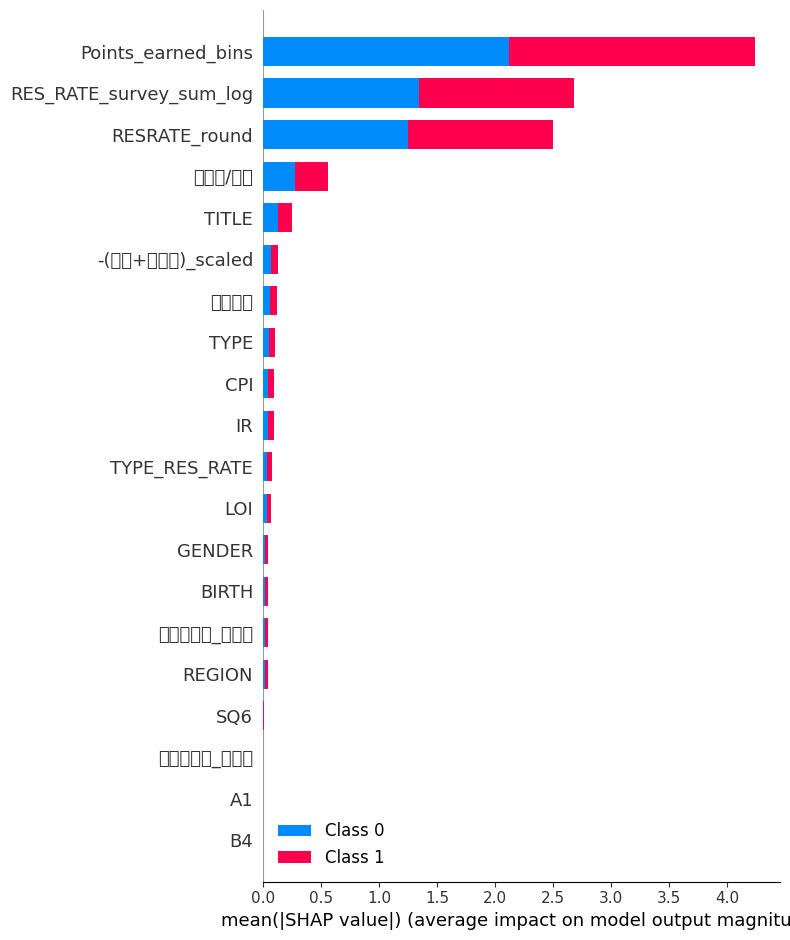

,column_name,shap_importance
21,Points_earned_bins,2.122195
24,RES_RATE_survey_sum_log,1.342573
19,RESRATE_round,1.248833
22,리워드/시간,0.280939
15,TITLE,0.127567
23,-(시간+난이도)_scaled,0.067219
25,대상지역,0.06185
3,TYPE,0.053559
18,CPI,0.048462
16,IR,0.048215


In [58]:
# SHAP values 
### 약 2분 소요

# DF, based on which importance is checked
X_importance = X_test

# # Explain model predictions using shap library:
#LGBM쓰면 빨리 돌려지니까 이걸로 피처 추가하는 거겠지
model = LGBMClassifier(random_state=0).fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_importance)

# Plot summary_plot as barplot:
shap.summary_plot(shap_values, X_importance, plot_type='bar') #shap_values피처 중요도 

shap_sum = np.abs(shap_values).mean(axis=1)[1,:]
importance_df = pd.DataFrame([X_importance.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
importance_df

In [59]:
# 지정된(SHAP_THRESHOLD) Shap feature 중요도 이상인 것만 선택
### 원래 143개였는데 117개됨
features_selected = importance_df.query('shap_importance > @SHAP_THRESHOLD').column_name.tolist()
X_train = X_train[features_selected]
X_test = X_test[features_selected]

print(X_train.shape)

(813650, 19)


<span style="color:#33FF33">

---

# 추가!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!(아현)

- w2v 중요도 낮은 거 삭제

In [60]:
'''# LGBM 모델 생성
lgbm_model = LGBMClassifier()
# 모델 학습
lgbm_model.fit(X_train, y_train)

# 중요도가 낮은 피처들 제거
threshold = 30  # 임계값 설정
low_importance_features = X_train.columns[lgbm_model.feature_importances_ < threshold]
print(low_importance_features)'''

'# LGBM 모델 생성\nlgbm_model = LGBMClassifier()\n# 모델 학습\nlgbm_model.fit(X_train, y_train)\n\n# 중요도가 낮은 피처들 제거\nthreshold = 30  # 임계값 설정\nlow_importance_features = X_train.columns[lgbm_model.feature_importances_ < threshold]\nprint(low_importance_features)'

In [61]:
'''X_train.drop(columns=low_importance_features, inplace=True)
X_test.drop(columns=low_importance_features, inplace=True)
result_features = [x for x in features if x not in low_importance_features]
print(len(result_features))
result_features'''

'X_train.drop(columns=low_importance_features, inplace=True)\nX_test.drop(columns=low_importance_features, inplace=True)\nresult_features = [x for x in features if x not in low_importance_features]\nprint(len(result_features))\nresult_features'

<span style="color:#33FF33">

---


In [62]:
### 피처 전체 순위
from lightgbm import LGBMClassifier

# LightGBM 모델 생성 및 학습
model = LGBMClassifier()
model.fit(X_train, y_train)

# 피처 중요도를 데이터프레임으로 변환
feature_importances = pd.DataFrame()
feature_importances['Feature'] = X_train.columns
feature_importances['Importance'] = model.feature_importances_

# 중요도를 기준으로 내림차순 정렬
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# 중요도 순위 출력
print("전체 피처의 중요도 순위:")
print(feature_importances)

[LightGBM] [Info] Number of positive: 316565, number of negative: 497085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 813650, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389068 -> initscore=-0.451232
[LightGBM] [Info] Start training from score -0.451232
전체 피처의 중요도 순위:
                    Feature  Importance
5          -(시간+난이도)_scaled         550
2             RESRATE_round         428
0        Points_earned_bins         350
3                    리워드/시간         334
8                       CPI         267
9                        IR         215
4                     TITLE         181
1   RES_RATE_survey_sum_log         136
7                      TYPE         100
13                    BIR

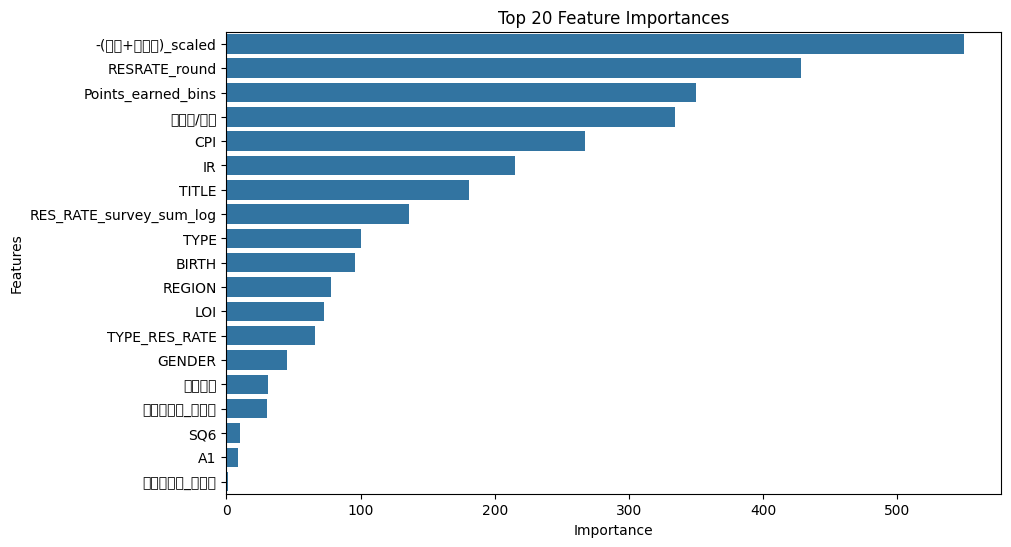

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 피처 중요도를 담은 데이터프레임이 있다고 가정
# feature_importances는 피처명과 중요도 값으로 구성된 데이터프레임이어야 합니다.
# 이 예시에서는 feature_importances라는 데이터프레임으로 가정합니다.

# 중요도를 기준으로 내림차순 정렬
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# 중요도에 따라 피처를 시각화 (상위 n개의 피처만 표시)
n = 20  # 상위 n개의 피처만 표시하도록 설정
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(n))
plt.title('Top {} Feature Importances'.format(n))
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


<font color="#CC3D3D"><p>
##### Save preprocessed data

- 전처리 계속 할거면 피클로 저장 하면 데이터 많으면힘드니까 데이터 압축해서저장

In [64]:
'''#
# 추후 사용을 위해 전처리된 데이터 압축해서 저장
#

with gzip.open('data_preprocessed.zip', 'wb') as f:
    pickle.dump([X_train, y_train, X_test, ID_test, cat_features, num_features], f)

# load and uncompress
#with gzip.open('data_preprocessed.zip','rb') as f:
#    X_train, y_train, X_test, ID_test, cat_features, num_features = pickle.load(f)'''

"#\n# 추후 사용을 위해 전처리된 데이터 압축해서 저장\n#\n\nwith gzip.open('data_preprocessed.zip', 'wb') as f:\n    pickle.dump([X_train, y_train, X_test, ID_test, cat_features, num_features], f)\n\n# load and uncompress\n#with gzip.open('data_preprocessed.zip','rb') as f:\n#    X_train, y_train, X_test, ID_test, cat_features, num_features = pickle.load(f)"

---
---
---

# **06. Model building**

- LGBM

In [65]:
model_lgbm = LGBMClassifier(n_estimators=2000,objective='binary', metric='binary_error', random_state=44)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_lgbm.fit(tr_x, tr_y, eval_metric = 'accuracy')
    pred = model_lgbm.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_lgbm.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_lgbm = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_lgbm)
print(f'{model_lgbm.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

[LightGBM] [Info] Number of positive: 253249, number of negative: 397671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389063 -> initscore=-0.451252
[LightGBM] [Info] Start training from score -0.451252
0.8608738401032385


1it [00:15, 15.78s/it]

[LightGBM] [Info] Number of positive: 253255, number of negative: 397665
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389072 -> initscore=-0.451213
[LightGBM] [Info] Start training from score -0.451213
0.859853745467953


2it [00:31, 15.84s/it]

...

[LightGBM] [Info] Number of positive: 253073, number of negative: 397847
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388793 -> initscore=-0.452390
[LightGBM] [Info] Start training from score -0.452390
0.8605235666441344


4it [01:02, 15.72s/it]

[LightGBM] [Info] Number of positive: 253186, number of negative: 397734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874
[LightGBM] [Info] Number of data points in the train set: 650920, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.388966 -> initscore=-0.451659
[LightGBM] [Info] Start training from score -0.451659
0.8594358753763903


5it [01:18, 15.73s/it]

[1 1 1 ... 0 0 1]
LGBMClassifier의 fold 평균 Accuracy는 0.8602187672832299


- XGB

In [66]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# 최적의 하이퍼파라미터 설정
best_params = {
    'n_estimators': 1146,
    'max_depth': 9,
    'learning_rate': 0.02534583366384355,
    'subsample': 0.85,
    'colsample_bytree': 0.9,
    'gamma': 0.03967425666846014,
    'min_child_weight': 4
}

model_xgb = XGBClassifier(**best_params, eval_metrics='error', objective='binary:logistic', random_state=0, verbose=200)
xgb_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
threshold = 0.5
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_xgb.fit(tr_x, tr_y)
    pred = model_xgb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_xgb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    xgb_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_xgb = (xgb_pred / spl >= 0.5).astype(int)
print(final_predictions_xgb)
print(f'{model_xgb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0.8608738401032385


1it [00:08,  8.92s/it]

0.859743132796657


2it [00:17,  8.88s/it]

...

0.8610151785165612


4it [00:35,  8.98s/it]

0.8597001167578197


5it [00:44,  8.92s/it]

[1 1 1 ... 0 0 1]
XGBClassifier의 fold 평균 Accuracy는 0.860479321575616


- CAT

In [67]:
model_cb = CatBoostClassifier(eval_metric= 'Accuracy',loss_function = "CrossEntropy", random_state=0, verbose = 200)
lgbm_pred = np.zeros((X_test.shape[0]))
accuracy_list = []
list_lgbm = []

threshold = 0.5 
spl = 5

kf = KFold(n_splits=spl, shuffle=True, random_state=42)

for tr_idx, val_idx in tqdm(kf.split(X_train, y_train)):
    tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    val_x, val_y = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    model_cb.fit(tr_x, tr_y)
    pred = model_cb.predict(val_x)

    accuracy = accuracy_score(val_y, pred)
    accuracy_list.append(accuracy)
    print(accuracy)
    
    sub_pred = np.array(model_cb.predict_proba(X_test)[:, 1])  # X_test에 대한 예측값 구하기
    lgbm_pred += sub_pred

# 최종 예측값 구하기 (5-fold의 평균값 사용)
final_predictions_cb = (lgbm_pred / spl >= 0.5).astype(int)
print(final_predictions_cb)
print(f'{model_cb.__class__.__name__}의 fold 평균 Accuracy는 {np.mean(accuracy_list)}')

0it [00:00, ?it/s]

0:	learn: 0.8299284	total: 93.8ms	remaining: 1m 33s
200:	learn: 0.8528821	total: 3.28s	remaining: 13s
400:	learn: 0.8559762	total: 6.38s	remaining: 9.53s
600:	learn: 0.8575616	total: 9.48s	remaining: 6.3s
800:	learn: 0.8585464	total: 12.6s	remaining: 3.14s
999:	learn: 0.8592884	total: 15.8s	remaining: 0us
0.8587230381613716


1it [00:16, 16.40s/it]

0:	learn: 0.8301850	total: 38.5ms	remaining: 38.5s
200:	learn: 0.8530756	total: 3.21s	remaining: 12.8s
400:	learn: 0.8563234	total: 6.36s	remaining: 9.5s
600:	learn: 0.8578105	total: 9.5s	remaining: 6.3s
800:	learn: 0.8586708	total: 12.7s	remaining: 3.15s


2it [00:32, 16.35s/it]

...

0:	learn: 0.8298301	total: 39.5ms	remaining: 39.5s
200:	learn: 0.8528621	total: 3.23s	remaining: 12.8s
400:	learn: 0.8560192	total: 6.36s	remaining: 9.5s
600:	learn: 0.8574633	total: 9.48s	remaining: 6.29s
800:	learn: 0.8584327	total: 12.6s	remaining: 3.14s


4it [01:05, 16.27s/it]

999:	learn: 0.8591670	total: 15.8s	remaining: 0us
0.8593129724082836
0:	learn: 0.8326753	total: 38.2ms	remaining: 38.2s
200:	learn: 0.8534290	total: 3.23s	remaining: 12.8s
400:	learn: 0.8562988	total: 6.38s	remaining: 9.54s
600:	learn: 0.8578243	total: 9.54s	remaining: 6.33s
800:	learn: 0.8587783	total: 12.7s	remaining: 3.16s
999:	learn: 0.8595112	total: 15.9s	remaining: 0us
0.8580286363915689


5it [01:21, 16.31s/it]

[1 1 1 ... 0 0 1]
CatBoostClassifier의 fold 평균 Accuracy는 0.8585681804215574


In [68]:
# 위 모델의 예측값을 더하고 모델 개수만큼 나누어 평균 계산
avg_predictions = (final_predictions_lgbm + final_predictions_xgb + final_predictions_cb) / 3

# 평균값을 기준으로 0 또는 1로 예측
threshold = 0.5  # 임계값 설정
final_predictions = np.where(avg_predictions >= threshold, 1, 0)

print(final_predictions)

[1 1 1 ... 0 0 1]


In [69]:
(0.8600467031278806+0.8604104959134764+0.8585804707183676)/3

0.8596792232532415

In [70]:
len(final_predictions)

541867

In [71]:
t = pd.Timestamp.now()
fname = f"oof_hardvoting2_{t.month:02}{t.day:02}{t.hour:02}{t.minute:02}.csv"
pd.DataFrame({'ID': ID_test, 'STATUS': final_predictions}).to_csv(fname, index=False)
print(f"'{fname}' is ready to submit.")

'oof_hardvoting2_12200148.csv' is ready to submit.
